# Step 2: Data and EDA

In [53]:
import pandas as pd 
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
# df = pd.read_csv('C:/Users/Jenna/OneDrive/Desktop/Statistics/Stat 486/Women_ML/data/clean_qol.csv')
# df = df.drop(columns='Unnamed: 0')
# df.head()

In [54]:
df2 = pd.read_csv('C:/Users/Jenna/OneDrive/Desktop/Statistics/Stat 486/Women_ML/data/smaller_qol.csv')
# drop first column Unnamed:0
df2 = df2.drop(columns='Unnamed: 0')
df2.head()

C:\Users\Jenna\AppData\Local\Temp\ipykernel_22584\3909598095.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('C:/Users/Jenna/OneDrive/Desktop/Statistics/Stat 486/Women_ML/data/smaller_qol.csv')


,year,id,sex,race,educ,lockedup,occ,relig,happy,hapmar,health,life
0,1972,1,female,white,16.0,NaN,205,3.0,not too happy,NaN,good,NaN
1,1972,2,male,white,10.0,NaN,441,2.0,not too happy,NaN,fair,NaN
2,1972,3,female,white,12.0,NaN,270,1.0,pretty happy,NaN,excellent,NaN
3,1972,4,female,white,17.0,NaN,1,5.0,not too happy,NaN,good,NaN
4,1972,5,female,white,12.0,NaN,385,1.0,pretty happy,NaN,good,NaN


In [55]:
# # Ordinal targets and features
# happy_map = {'not too happy': 0, 'pretty happy': 1, 'very happy': 2}
# health_map = {'poor': 1, 'fair': 2, 'good': 3, 'excellent': 4}
# life_map = {'dull': 0, 'routine': 1, 'exciting': 2}

# df['happy_encoded'] = df['happy'].map(happy_map)
# df['health_encoded'] = df['health'].map(health_map)
# df['life_encoded'] = df['life'].map(life_map)

# # Binary
# df['sex_binary'] = df['sex'].map({'male': 0, 'female': 1})
# df['lockedup_binary'] = df['lockedup'].map({'no': 0, 'yes': 1})

# # Nominal — one-hot with reference category dropped
# race_dummies = pd.get_dummies(df['race'], prefix='race', drop_first=True)
# df = pd.concat([df, race_dummies], axis=1)

# # occ — group first, then encode
# # (fill in your grouping logic from the GSS codebook)
# occ_dummies = pd.get_dummies(df['occ_grouped'], prefix='occ', drop_first=True)
# df = pd.concat([df, occ_dummies], axis=1)

**Research Question:** What demographic and attitudinal factors predict happiness in American women, and do anomalously happy or unhappy women share identifiable characteristics?

**Data Description:** 
*What it is*
The General Social Survey (GSS) is a nationally representative, cross-sectional survey of non-institutionalized English and Spanish-speaking adults in the United States. It has been conducted by NORC at the University of Chicago since 1972, funded continuously by the National Science Foundation. It is widely regarded as the single most important source of longitudinal attitudinal data in American social science.

**How data is collected**
1972–2018: in-person face-to-face interviews using probability sampling. 2021–present: address-based sampling with push-to-web and mixed-mode (web, phone, in-person). Sampling is designed to be nationally representative of U.S. adults at each wave.

**Data Legitimacy:** GSS is NSF (National Science Foundation) funded and peer-reviewd. It uses a multi-state probability sample designed to represent all of the U.S. population. GSS is also widely used in ML and social science publications and research. 

**Legal and Ethical Appropriateness:** 
* NORC explicitly grants free use of the GSS public use file for research, teaching, and analysis. 

* Privacy is ensured because the GSS public use file contains no names, addresses, or unique identifiers. 

* Sex is recorded as a binary variable so this will not reflect the 2021+ waves of gender identify questions. 

* We also need to be sure that our narrative should center structural and social predictors — work conditions, income inequality, caregiving burden — rather than implying something intrinsic.


**Variables:** 
* satjob (Job Satisfaction)
* marital / childs (Marital Status and # of children)
* rincome / coninc (Respondent income and inflation-adjusted income)
* health (Self-rates health status)
* sex / sexnow (Respondent sex/gender — core analytical variable)
* fefam / fepol (Gender attitude variables — do beliefs affect happiness?)
* educ / degree (Years of education and highest degree)
* age / year (Age and survey year — for temporal trend analysis)
* region / srcbelt (Geographic region and urbanicity)

**Target:** 
* happy (Self-reported happiness (3-point scale) — your primary target)

## Summary Statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75699 entries, 0 to 75698
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      75699 non-null  int64  
 1   id        75699 non-null  int64  
 2   sex       75568 non-null  object 
 3   race      75527 non-null  object 
 4   educ      75413 non-null  float64
 5   lockedup  1748 non-null   object 
 6   occ       75699 non-null  object 
 7   relig     71953 non-null  float64
 8   happy     70869 non-null  object 
 9   hapmar    35350 non-null  object 
 10  health    58448 non-null  object 
 11  life      46463 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 6.9+ MB


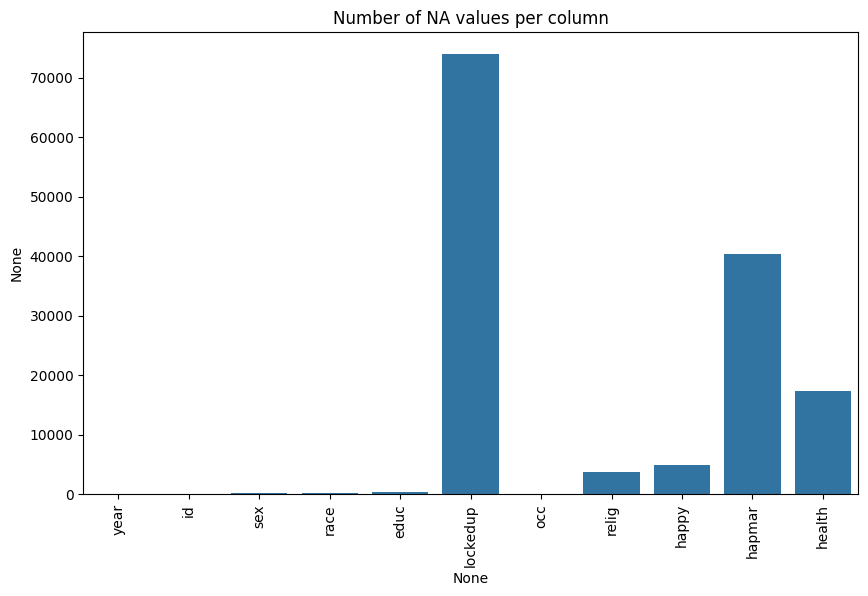

In [56]:
df2.info()
plt.figure(figsize=(10,6))
sns.barplot(x=df2.columns[:-1], y=df2.isna().sum()[:-1])
plt.xticks(rotation=90)
plt.title('Number of NA values per column')
plt.show()

After these 2 plots df2 (smaller gss dataset) might be the better option because it only has 1 column with a lot of NA's.

In [57]:
# ordinal order health
def health_new(x):
    if x == 'excellent':
        return 4
    elif x == 'good':
        return 3
    elif x == 'fair':
        return 2
    else:
        return 1
df2['health_new'] = df2['health'].apply(health_new)

# ordinal order life
def life_new(x):
    if x == 'exciting':
        return 3
    elif x == 'routine':
        return 2
    else:
        return 1
df2['life_new'] = df2['life'].apply(life_new)

# sex as male = 0 and female = 1
def sex_new(x):
    if x == 'male':
        return 0        
    else:        return 1
df2['sex_new'] = df2['sex'].apply(sex_new)  

# make a new column of happy as happy_new with 1 = pretty happy, 2 = very happy, 0 = not too happy
def happy_new(x):
    if x == 'pretty happy':
        return 1
    elif x == 'very happy':
        return 2
    else:
        return 0
df2['happy_new'] = df2['happy'].apply(happy_new)
df2.head()

,year,id,sex,race,educ,lockedup,occ,relig,happy,hapmar,health,life,health_new,life_new,sex_new,happy_new
0,1972,1,female,white,16.0,NaN,205,3.0,not too happy,NaN,good,NaN,3,1,1,0
1,1972,2,male,white,10.0,NaN,441,2.0,not too happy,NaN,fair,NaN,2,1,0,0
2,1972,3,female,white,12.0,NaN,270,1.0,pretty happy,NaN,excellent,NaN,4,1,1,1
3,1972,4,female,white,17.0,NaN,1,5.0,not too happy,NaN,good,NaN,3,1,1,0
4,1972,5,female,white,12.0,NaN,385,1.0,pretty happy,NaN,good,NaN,3,1,1,1


In [75]:
# --- encode race dummies from df2 if not already done ---
# if you already ran get_dummies on df2 for race, grab those columns
# otherwise create them fresh here too
race_dummies = pd.get_dummies(df2['race'], prefix='race', drop_first=True)

lockedup_dummies = pd.get_dummies(df2['lockedup'], prefix='lockedup', drop_first=True)

# --- build df_new from scratch ---
df_new = pd.concat([
    df2['happy_new'],
    df2['health_new'],
    df2['life_new'],
    df2['sex_new'],
    race_dummies,
    lockedup_dummies,
    df2['relig'],
    df2['occ'],
    df2['educ'],
    df2['year'],
], axis=1)

# --- verify ---
print(df_new.shape)
print(df_new.dtypes)
print(df_new.isnull().sum())

(75699, 11)
happy_new         int64
health_new        int64
life_new          int64
sex_new           int64
race_other         bool
race_white         bool
lockedup_yes       bool
relig           float64
occ              object
educ            float64
year              int64
dtype: object
happy_new          0
health_new         0
life_new           0
sex_new            0
race_other         0
race_white         0
lockedup_yes       0
relig           3746
occ                0
educ             286
year               0
dtype: int64


# Note for team: we need to add age and marital status!!

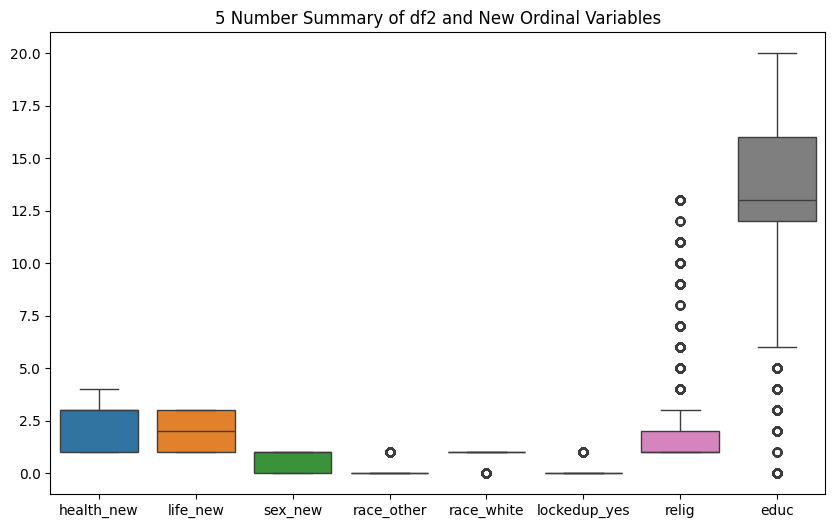

In [76]:
# boxplot showing 5 number summary of df2
plt.figure(figsize=(10,6))
sns.boxplot(data=df_new.drop(columns=['happy_new', 'year']))
plt.title('5 Number Summary of df2 and New Ordinal Variables')
plt.show()

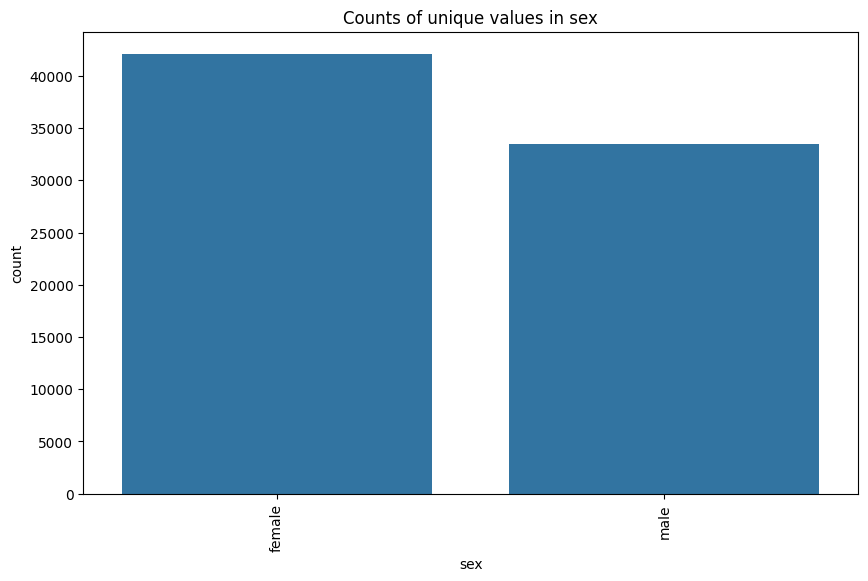

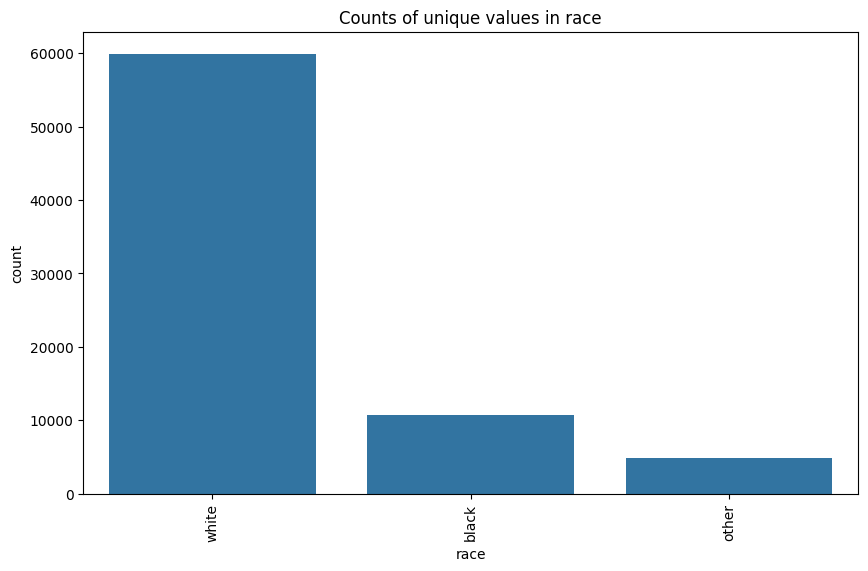

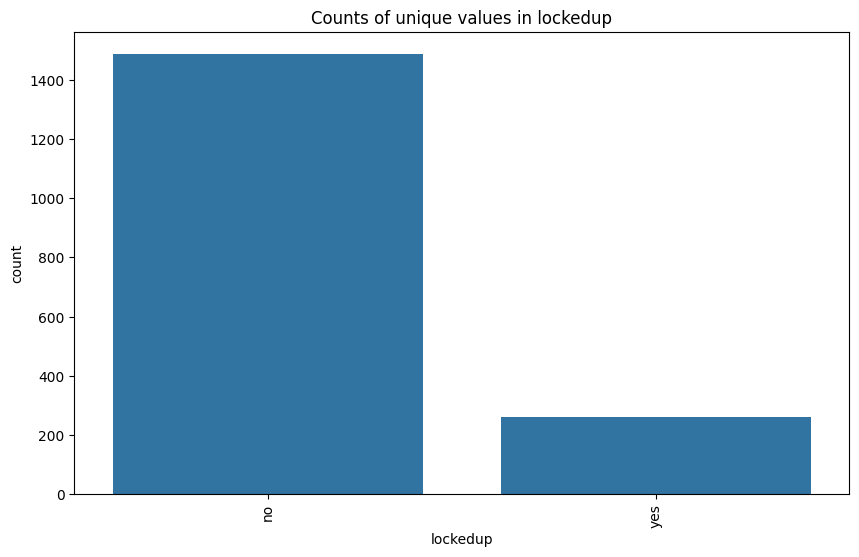

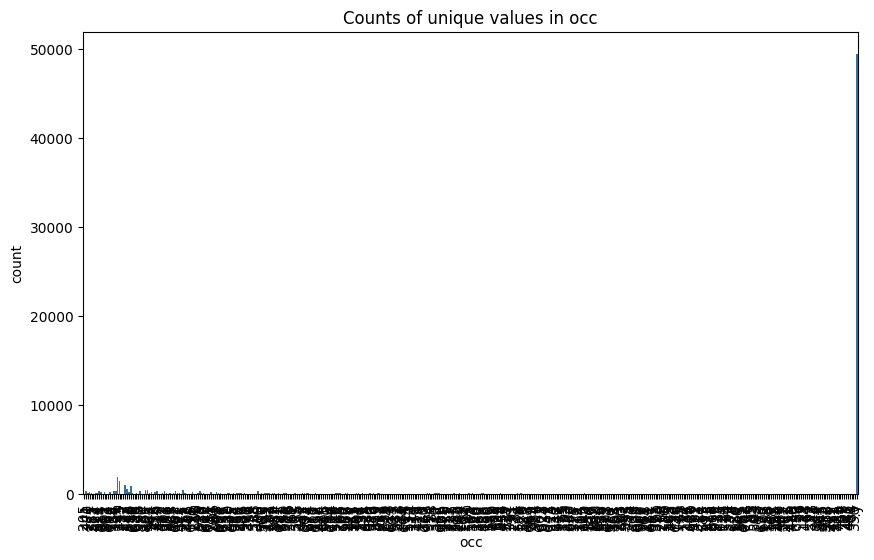

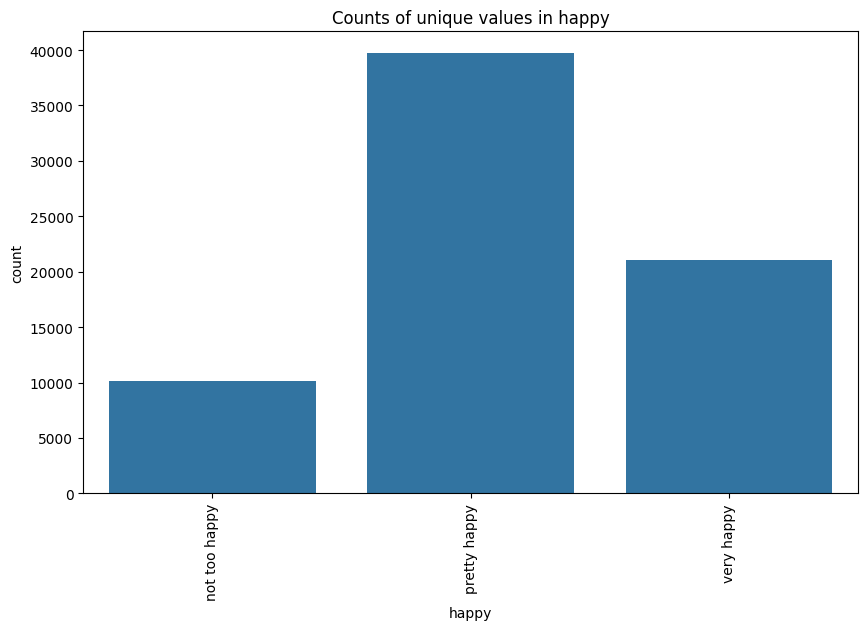

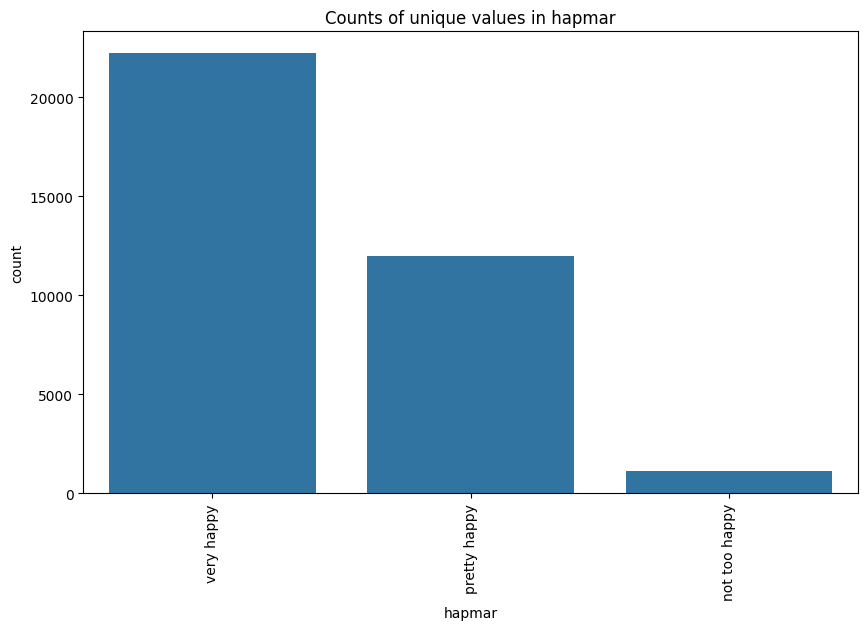

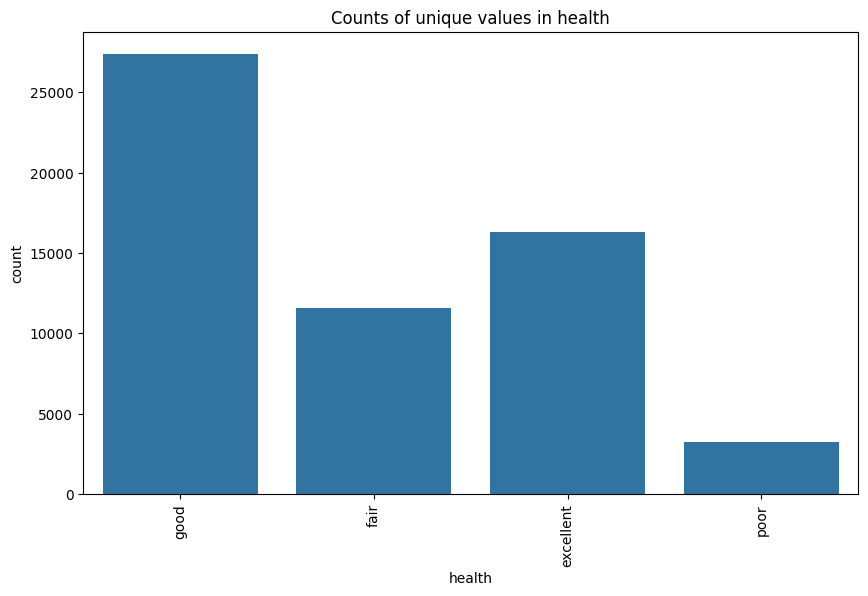

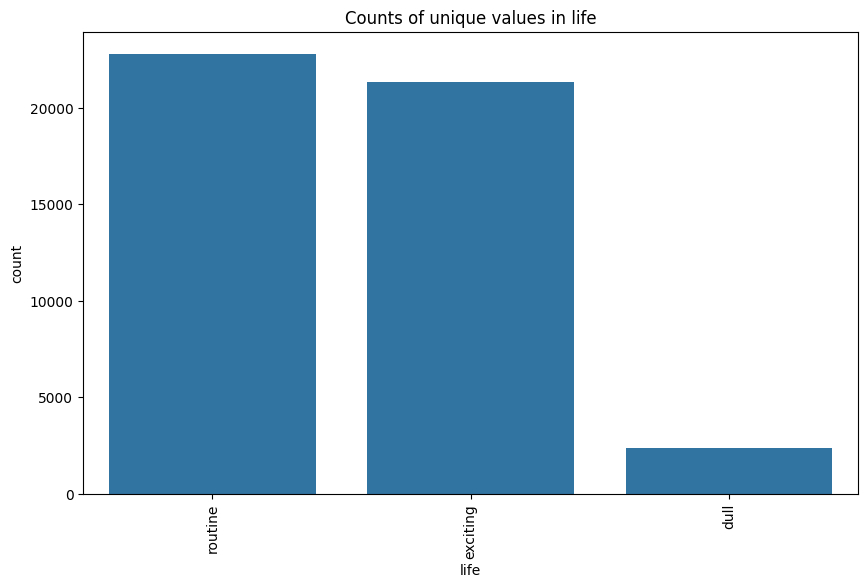

In [77]:
# for each non-numeric column in df2, make a bar plot of the counts of each unique value
for col in df2.columns:
    if df2[col].dtype == 'object':
        plt.figure(figsize=(10,6))
        sns.countplot(x=df2[col])
        plt.xticks(rotation=90)
        plt.title(f'Counts of unique values in {col}')
        plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of df_new')

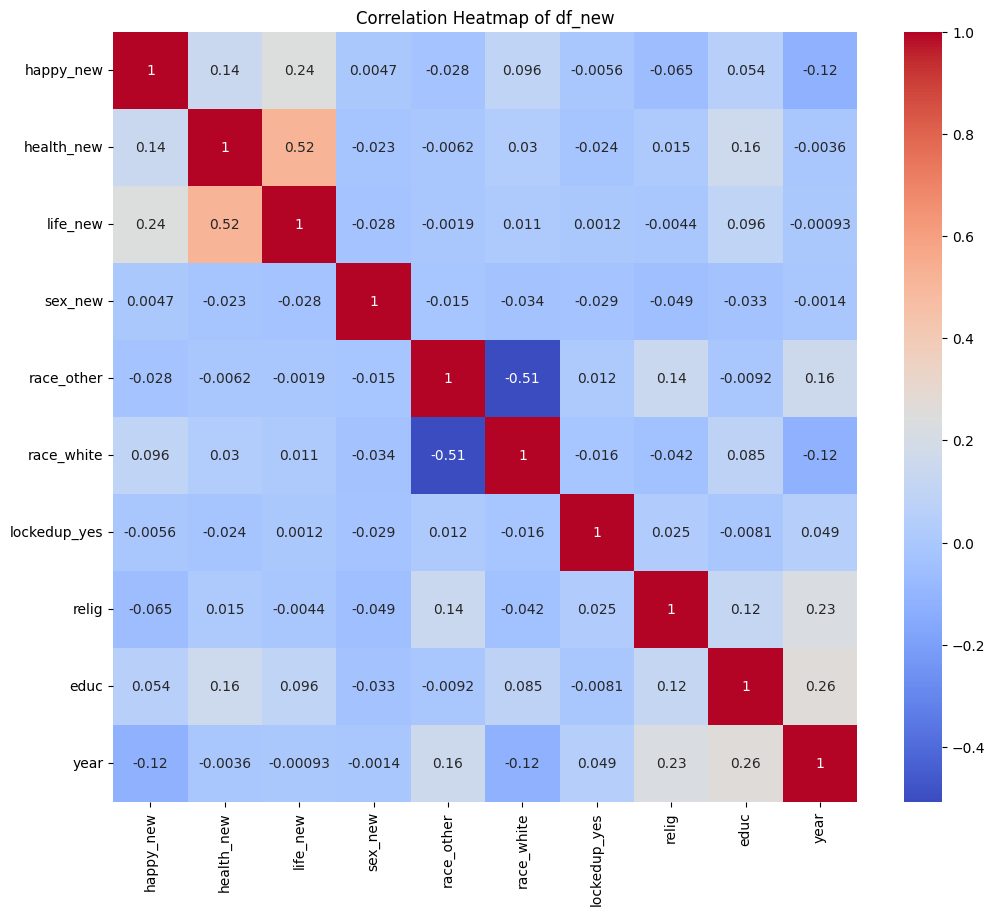

In [79]:
# correlation plot head map of df_new
# drop occ column
plt.figure(figsize=(12,10))
sns.heatmap(df_new.drop(columns=['occ']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of df_new')

## EDA (2 visualizations)

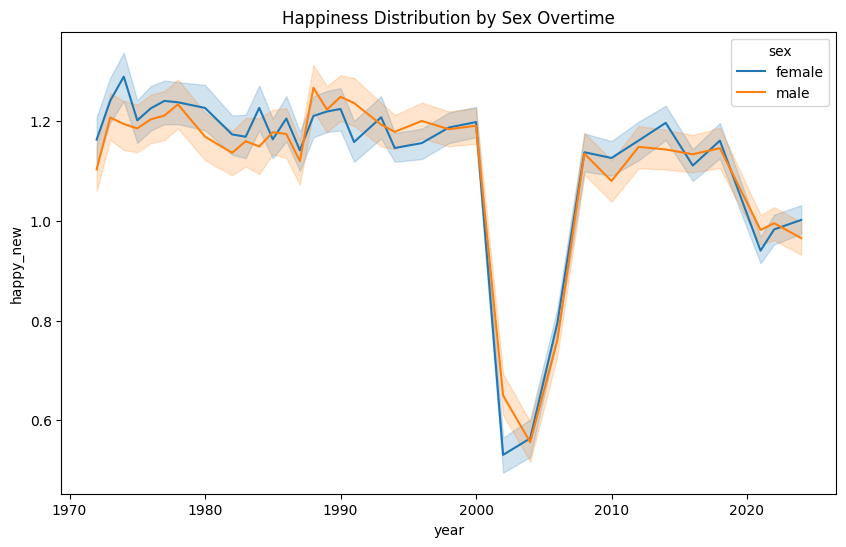

In [80]:
# happyiness distrbution by sex overtime
plt.figure(figsize=(10,6))
sns.lineplot(x='year', y='happy_new', hue='sex', data=df2)
plt.title('Happiness Distribution by Sex Overtime')
plt.show()

The figure above displays mean happiness scores (coded 0 = not too happy, 1 = pretty happy, 2 = very happy) for female and male respondents across GSS survey years from 1972 to 2024. 

From 1972 through the early 2000s, women consistently reported slightly higher average happiness than men, reproducing the female happiness advantage documented in prior literature. However, this gap narrows substantially beginning around 2006–2008, with the two groups converging by the mid-2010s — a pattern consistent with Stevenson and Wolfers' (2009) finding of declining relative female happiness in the United States. 

A notable anomaly appears in the 2002–2004 waves, where mean scores drop sharply for both sexes before rebounding; this likely reflects a methodological change in the GSS instrument rather than a true behavioral shift and warrants further investigation. Additionally, both groups show a decline in reported happiness in the 2021–2024 waves, which may reflect pandemic-era wellbeing effects compounded by the GSS transition to web-based data collection introduced in 2021.

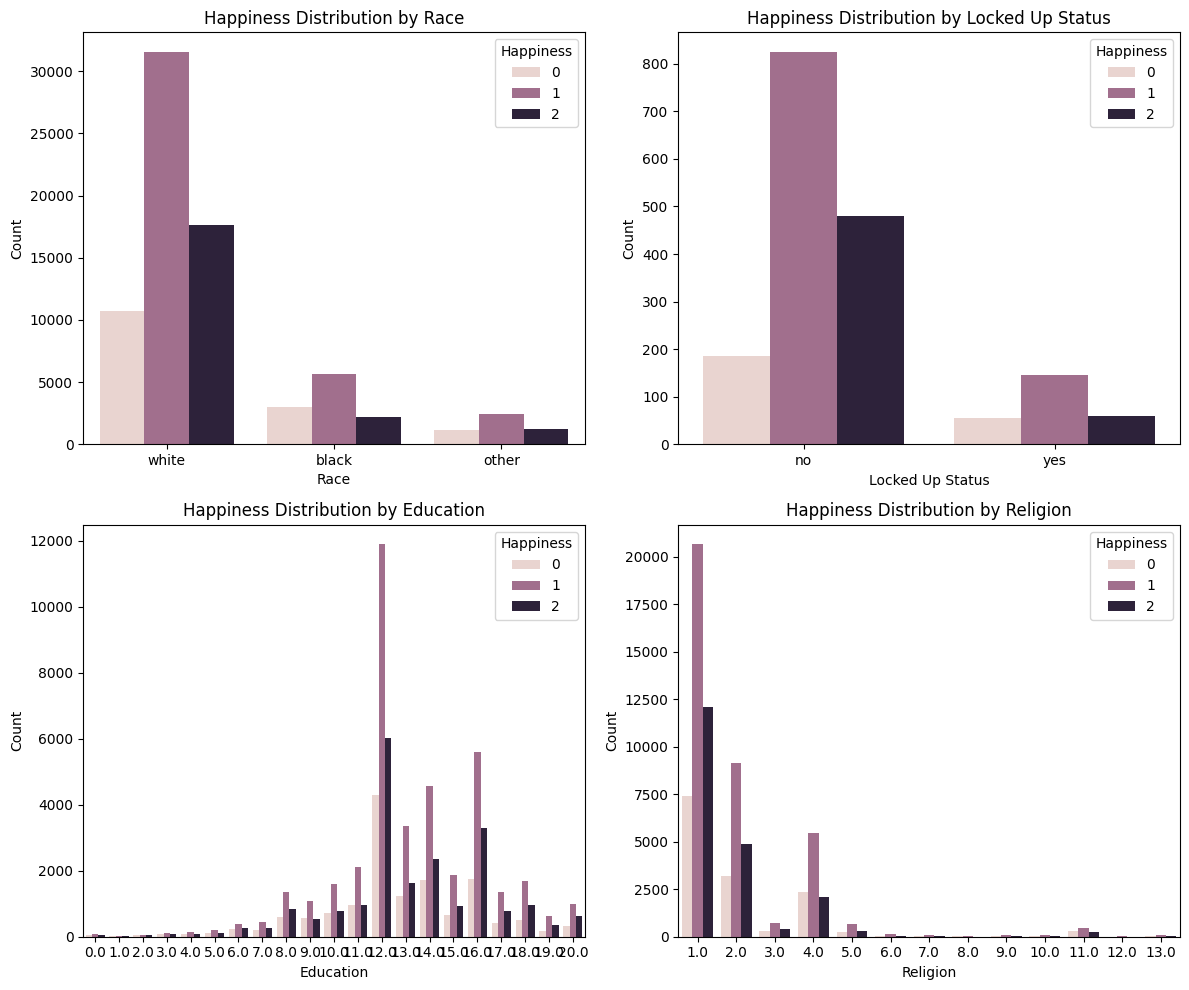

In [ ]:
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.countplot(x='race', hue='happy_new', data=df2)
plt.title('Happiness Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.legend(title='Happiness')

plt.subplot(2,2,2)
sns.countplot(x='lockedup', hue='happy_new', data=df2)
plt.title('Happiness Distribution by Locked Up Status')
plt.xlabel('Locked Up Status')
plt.ylabel('Count')
plt.legend(title='Happiness')

plt.subplot(2,2,3)
sns.countplot(x='educ', hue='happy_new', data=df2)
plt.title('Happiness Distribution by Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.legend(title='Happiness')

plt.subplot(2,2,4)
sns.countplot(x='relig', hue='happy_new', data=df2)
plt.title('Happiness Distribution by Religion')
plt.xlabel('Religion')
plt.ylabel('Count')
plt.legend(title='Happiness')

plt.tight_layout()
plt.show()



Out of all 4 plots above, most people reported being pretty happy. 

We will need to look back at the GSS data record to find out the education level 12.0 and 1.0 religion. I am curious to know what those 2 variables are since most people reported as such (e.g., christian, teacher). 

Out of the four variables, there is not category where "very well" is out numbering the rest. This will be interesting to find as no 1 variable in the plot above or in the correlation plot a few cells above strongly influences happiness levels.